In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

train = pd.read_csv("../datasets/walmart/train.csv")
features = pd.read_csv("../datasets/walmart/features.csv")
stores = pd.read_csv("../datasets/walmart/stores.csv")

print("Train shape:", train.shape)
print("Features shape:", features.shape)
print("Stores shape:", stores.shape)

Train shape: (421570, 5)
Features shape: (8190, 12)
Stores shape: (45, 3)


In [4]:
print("TRAIN DATA")
print(train.head())

print("\nCOLUMNS")
print(train.columns.tolist())

print("\nDATA TYPES")
print(train.dtypes)

TRAIN DATA
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

COLUMNS
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

DATA TYPES
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object


In [5]:
print("Missing values in Train:")
print(train.isnull().sum())

print("\nDuplicate rows:", train.duplicated().sum())

Missing values in Train:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Duplicate rows: 0


In [6]:
train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


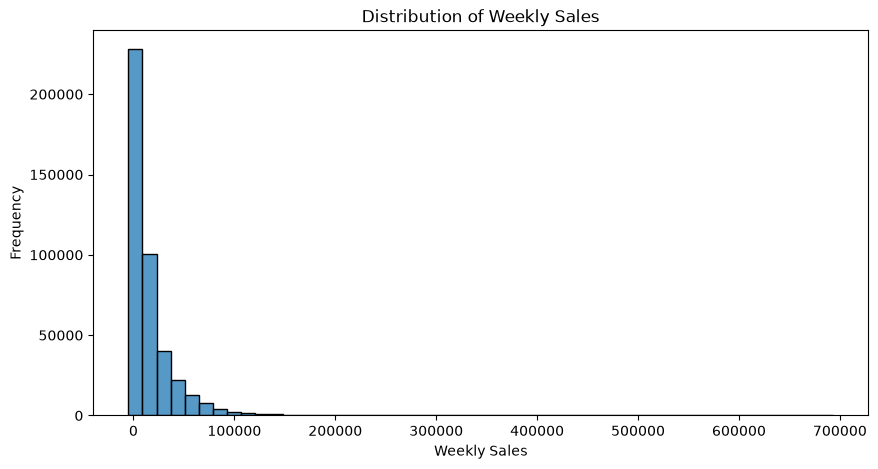

In [7]:
plt.figure(figsize=(10, 5))

sns.histplot(train["Weekly_Sales"], bins=50)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.show()

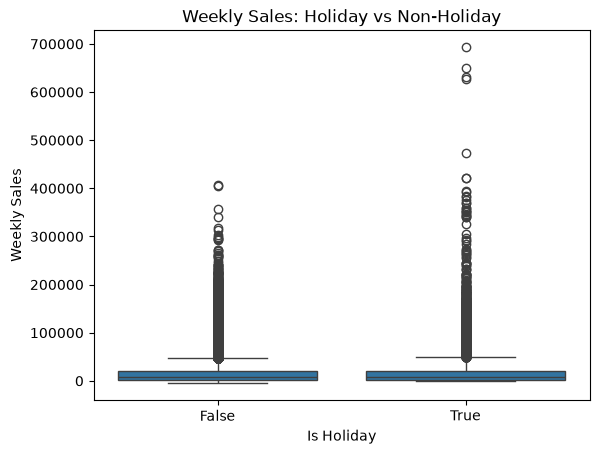

In [8]:
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=train)

plt.title("Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Is Holiday")
plt.ylabel("Weekly Sales")

plt.show()

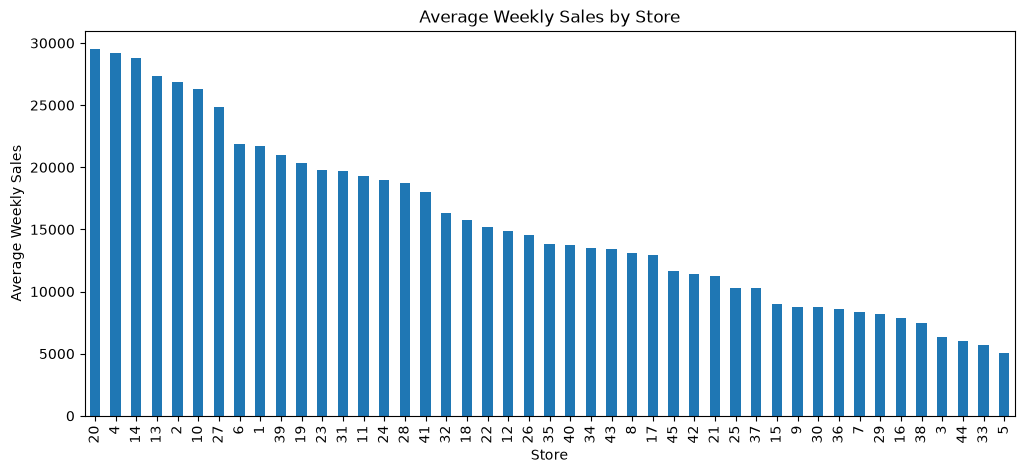

In [9]:
store_sales = train.groupby("Store")["Weekly_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))

store_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")

plt.show()

In [10]:
train["Date"] = pd.to_datetime(train["Date"])

print(train["Date"].min())
print(train["Date"].max())

2010-02-05 00:00:00
2012-10-26 00:00:00


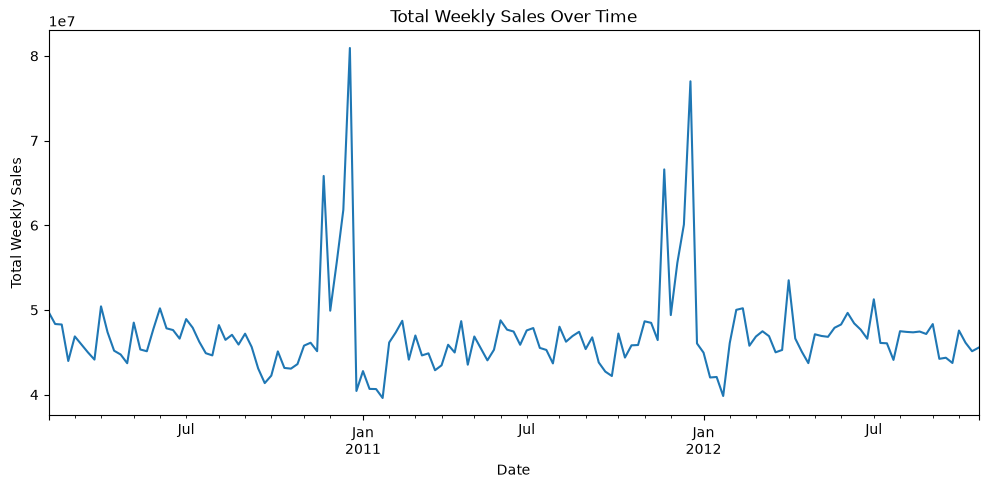

In [11]:
weekly_trend = train.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(12, 5))

weekly_trend.plot()

plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")

plt.show()

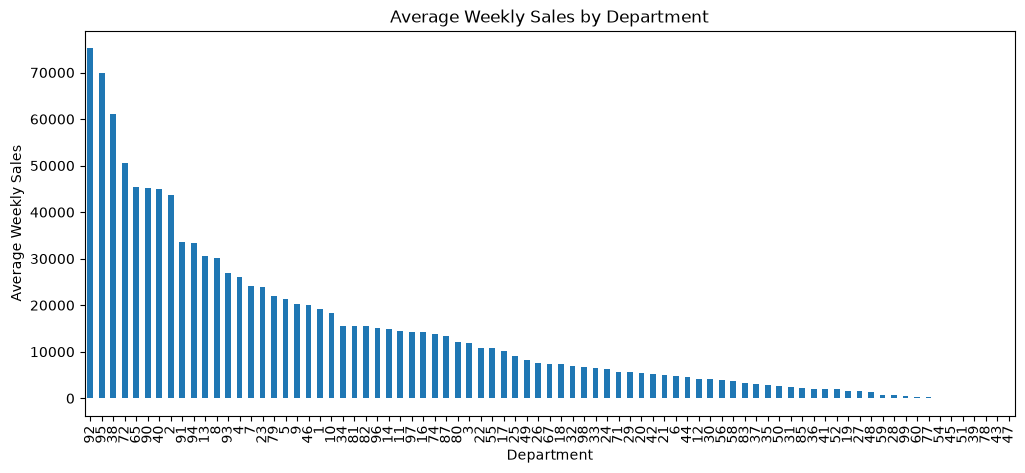

In [12]:
dept_sales = train.groupby("Dept")["Weekly_Sales"].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))

dept_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Department")
plt.xlabel("Department")
plt.ylabel("Average Weekly Sales")

plt.show()

In [13]:
holiday_sales = train.groupby("IsHoliday")["Weekly_Sales"].mean()

print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


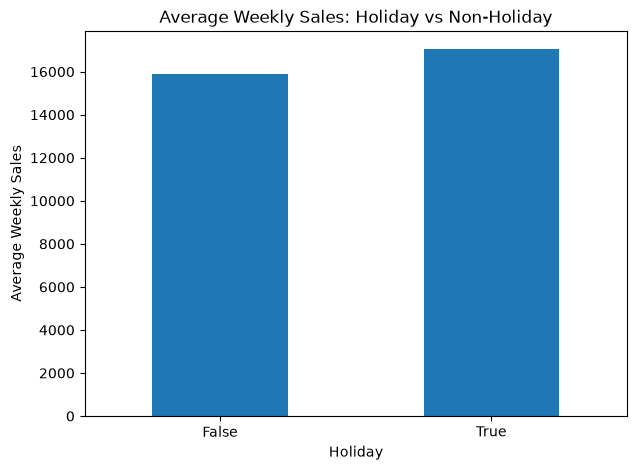

In [14]:
plt.figure(figsize=(7, 5))

holiday_sales.plot(kind="bar")

plt.title("Average Weekly Sales: Holiday vs Non-Holiday")
plt.xlabel("Holiday")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)

plt.show()

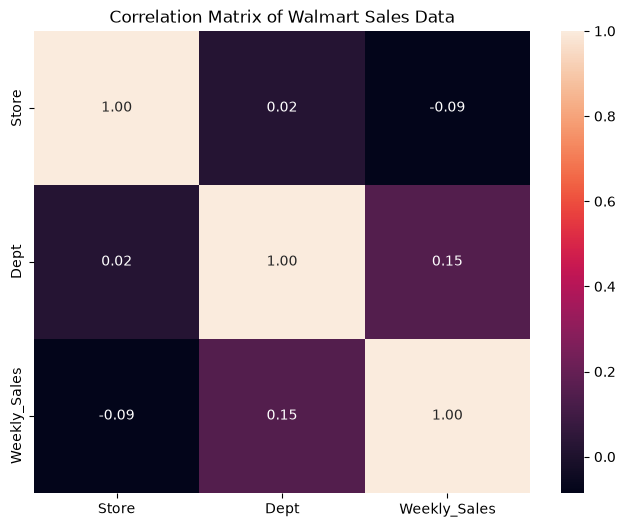

In [15]:
numeric_cols = train.select_dtypes(include="number")

correlation = numeric_cols.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Correlation Matrix of Walmart Sales Data")

plt.show()

In [16]:
print("FEATURES DATA")
print(features.head())

print("\nCOLUMNS")
print(features.columns.tolist())

print("\nDATA TYPES")
print(features.dtypes)

FEATURES DATA
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211.289143         8.106      False  
3        NaN        NaN        NaN  211.319643         8.106      False  
4        NaN        NaN        NaN  211.350143         8.106      False  

COLUMNS
['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDo

In [17]:
print("Missing values in Features:")
print(features.isnull().sum())

Missing values in Features:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


In [18]:
print("FEATURES DATASET SHAPE:")
print(features.shape)

print("\nFEATURES DATASET INFO:")
features.info()

print("\nFIRST 5 ROWS:")
display(features.head())

FEATURES DATASET SHAPE:
(8190, 12)

FEATURES DATASET INFO:
<class 'pandas.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   str    
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), str(1)
memory usage: 712.0 KB

FIRST 5 ROWS:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [19]:
features.describe()

,Store,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,8190.000000,8190.000000,8190.000000,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000,7605.000000,7605.000000
mean,23.000000,59.356198,3.405992,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422,172.460809,7.826821
std,12.987966,18.678607,0.431337,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278,39.738346,1.877259
min,1.000000,-7.290000,2.472000,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000,126.064000,3.684000
25%,12.000000,45.902500,3.041000,1577.532500,68.880000,6.600000,304.687500,1440.827500,132.364839,6.634000
50%,23.000000,60.710000,3.513000,4743.580000,364.570000,36.260000,1176.425000,2727.135000,182.764003,7.806000
75%,34.000000,73.880000,3.743000,8923.310000,2153.350000,163.150000,3310.007500,4832.555000,213.932412,8.567000
max,45.000000,101.950000,4.468000,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000,228.976456,14.313000


In [20]:
print("Duplicate rows:", features.duplicated().sum())

Duplicate rows: 0


In [21]:
features["Date"] = pd.to_datetime(features["Date"])

print("Date range:")
print(features["Date"].min())
print(features["Date"].max())

Date range:
2010-02-05 00:00:00
2013-07-26 00:00:00


In [22]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

features[markdown_cols].describe()

,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5
count,4032.000000,2921.000000,3613.000000,3464.000000,4050.000000
mean,7032.371786,3384.176594,1760.100180,3292.935886,4132.216422
std,9262.747448,8793.583016,11276.462208,6792.329861,13086.690278
min,-2781.450000,-265.760000,-179.260000,0.220000,-185.170000
25%,1577.532500,68.880000,6.600000,304.687500,1440.827500
50%,4743.580000,364.570000,36.260000,1176.425000,2727.135000
75%,8923.310000,2153.350000,163.150000,3310.007500,4832.555000
max,103184.980000,104519.540000,149483.310000,67474.850000,771448.100000


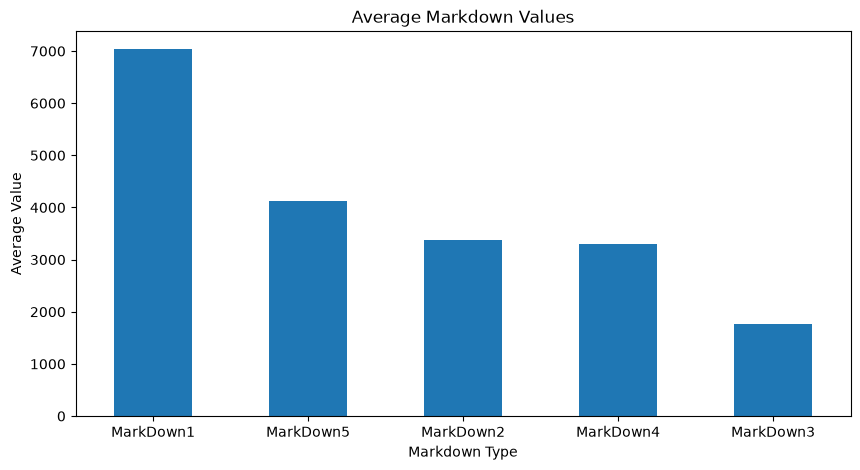

In [23]:
markdown_means = features[markdown_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))

markdown_means.plot(kind="bar")

plt.title("Average Markdown Values")
plt.xlabel("Markdown Type")
plt.ylabel("Average Value")
plt.xticks(rotation=0)

plt.show()

In [24]:
economic_cols = [
    "Fuel_Price",
    "CPI",
    "Unemployment"
]

features[economic_cols].describe()

,Fuel_Price,CPI,Unemployment
count,8190.000000,7605.000000,7605.000000
mean,3.405992,172.460809,7.826821
std,0.431337,39.738346,1.877259
min,2.472000,126.064000,3.684000
25%,3.041000,132.364839,6.634000
50%,3.513000,182.764003,7.806000
75%,3.743000,213.932412,8.567000
max,4.468000,228.976456,14.313000


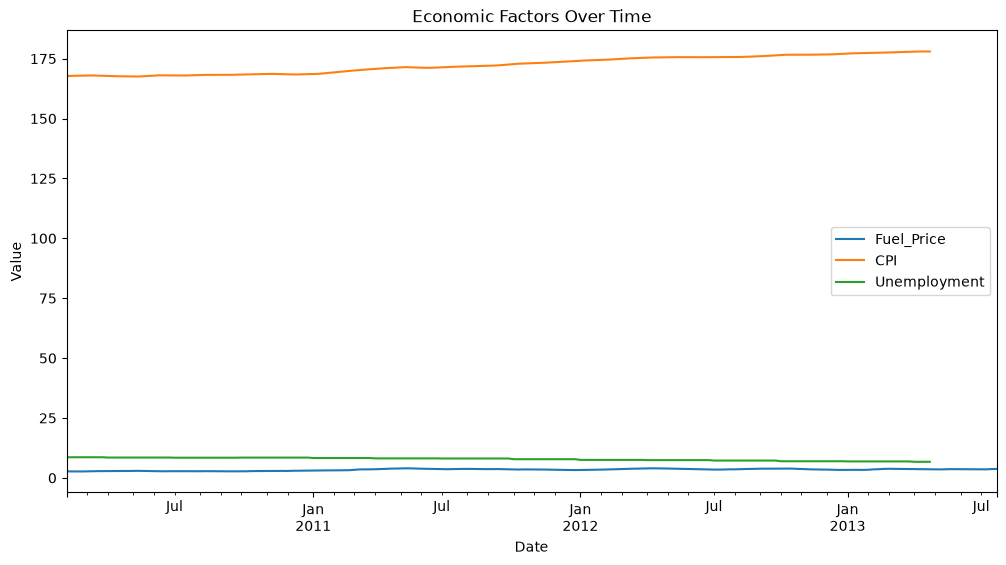

In [25]:
economic_trend = features.groupby("Date")[economic_cols].mean()

economic_trend.plot(figsize=(12, 6))

plt.title("Economic Factors Over Time")
plt.xlabel("Date")
plt.ylabel("Value")

plt.show()

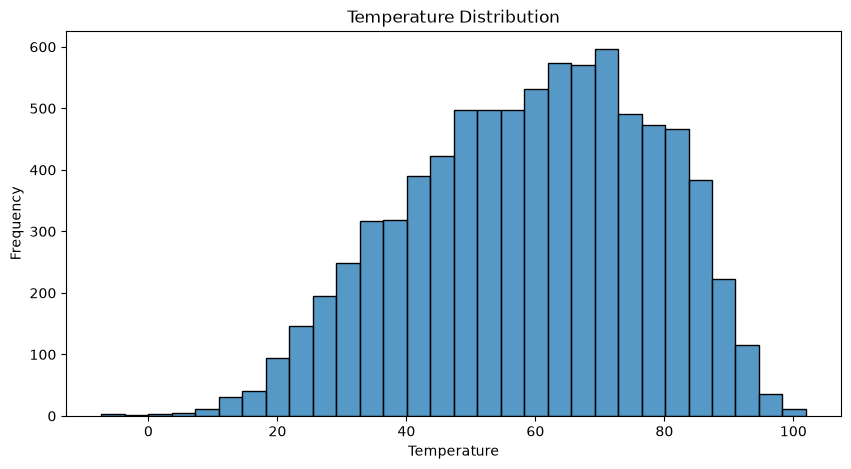

In [26]:
plt.figure(figsize=(10, 5))

sns.histplot(features["Temperature"].dropna(), bins=30)

plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.show()

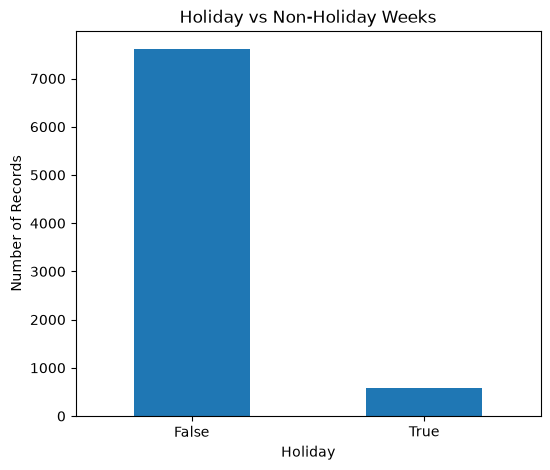

In [27]:
holiday_counts = features["IsHoliday"].value_counts()

plt.figure(figsize=(6, 5))

holiday_counts.plot(kind="bar")

plt.title("Holiday vs Non-Holiday Weeks")
plt.xlabel("Holiday")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

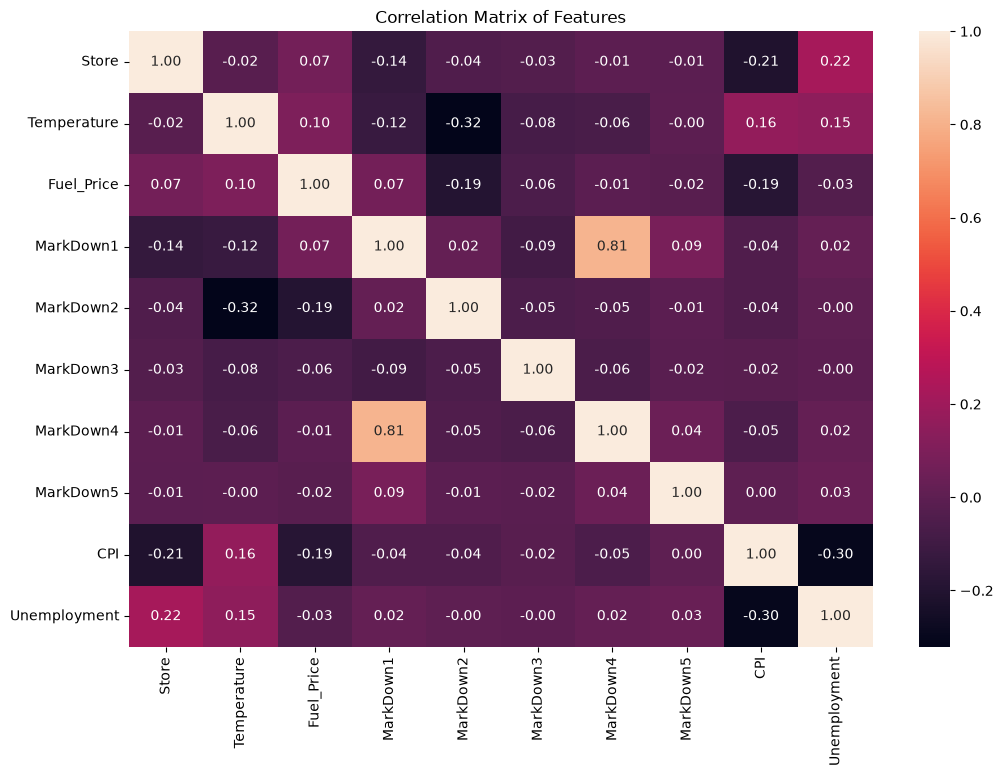

In [28]:
feature_numeric = features.select_dtypes(include="number")

plt.figure(figsize=(12, 8))

sns.heatmap(
    feature_numeric.corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix of Features")

plt.show()

In [29]:
train_features = pd.merge(
    train,
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

print("Shape after merging train + features:")
print(train_features.shape)

display(train_features.head())

Shape after merging train + features:
(421570, 14)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


In [30]:
final_data = pd.merge(
    train_features,
    stores,
    on="Store",
    how="left"
)

print("Final dataset shape:")
print(final_data.shape)

display(final_data.head())

Final dataset shape:
(421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [31]:
print("Final columns:")
print(final_data.columns.tolist())

Final columns:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']


In [32]:
missing = final_data.isnull().sum()

print(missing[missing > 0])

MarkDown1    270889
MarkDown2    310322
MarkDown3    284479
MarkDown4    286603
MarkDown5    270138
dtype: int64


In [33]:
print("Final dataset shape:", final_data.shape)

print("\nColumn names:")
print(final_data.columns.tolist())

print("\nData types:")
print(final_data.dtypes)

Final dataset shape: (421570, 16)

Column names:
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

Data types:
Store                    int64
Dept                     int64
Date            datetime64[us]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                       str
Size                     int64
dtype: object


In [34]:
print("Missing values:")
print(final_data.isnull().sum())

Missing values:
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64


In [35]:
print("Duplicate rows:", final_data.duplicated().sum())

Duplicate rows: 0


In [36]:
final_data.describe()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000
std,12.785297,30.492054,NaN,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328


In [37]:
negative_sales = final_data[final_data["Weekly_Sales"] < 0]

print("Number of negative sales records:", len(negative_sales))
print("Total negative sales:", negative_sales["Weekly_Sales"].sum())

Number of negative sales records: 1285
Total negative sales: -88161.56


In [38]:
clean_data = final_data.copy()

print("Original dataset:", final_data.shape)
print("Working dataset:", clean_data.shape)

Original dataset: (421570, 16)
Working dataset: (421570, 16)


Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


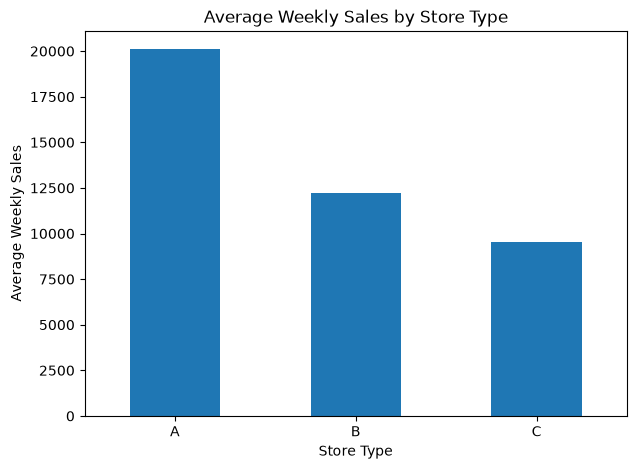

In [39]:
store_type_sales = final_data.groupby("Type")["Weekly_Sales"].mean().sort_values(ascending=False)

print(store_type_sales)

plt.figure(figsize=(7, 5))

store_type_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)

plt.show()

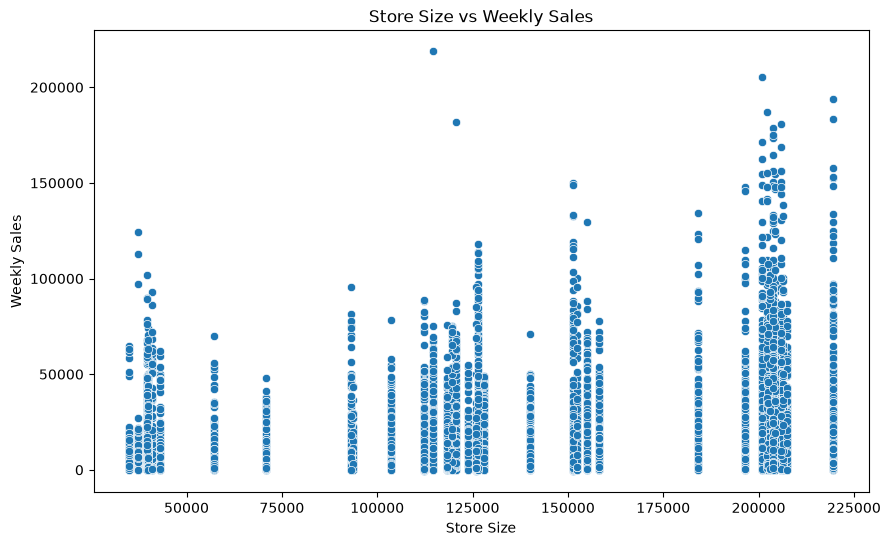

In [40]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_data.sample(10000, random_state=42),
    x="Size",
    y="Weekly_Sales"
)

plt.title("Store Size vs Weekly Sales")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")

plt.show()

Correlation of Markdown variables with Weekly Sales:
MarkDown1    0.085251
MarkDown2    0.024130
MarkDown3    0.060385
MarkDown4    0.045414
MarkDown5    0.090362
Name: Weekly_Sales, dtype: float64


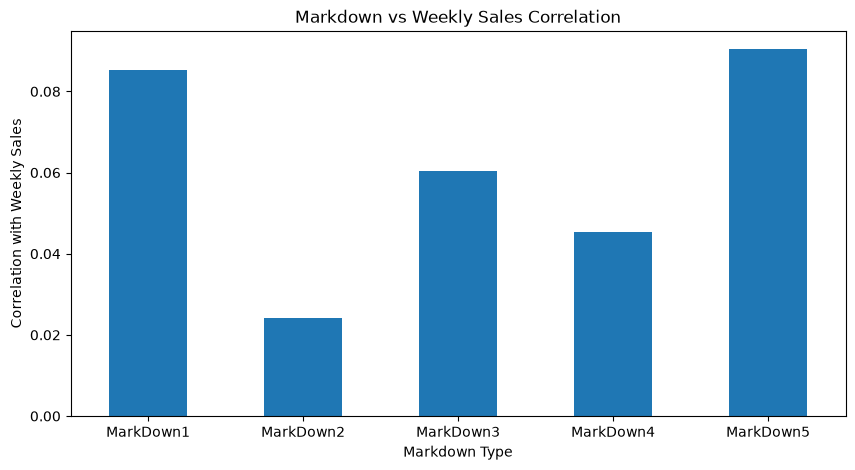

In [41]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

markdown_sales = final_data[markdown_cols + ["Weekly_Sales"]].corr()["Weekly_Sales"].drop("Weekly_Sales")

print("Correlation of Markdown variables with Weekly Sales:")
print(markdown_sales)

plt.figure(figsize=(10, 5))

markdown_sales.plot(kind="bar")

plt.title("Markdown vs Weekly Sales Correlation")
plt.xlabel("Markdown Type")
plt.ylabel("Correlation with Weekly Sales")
plt.xticks(rotation=0)

plt.show()

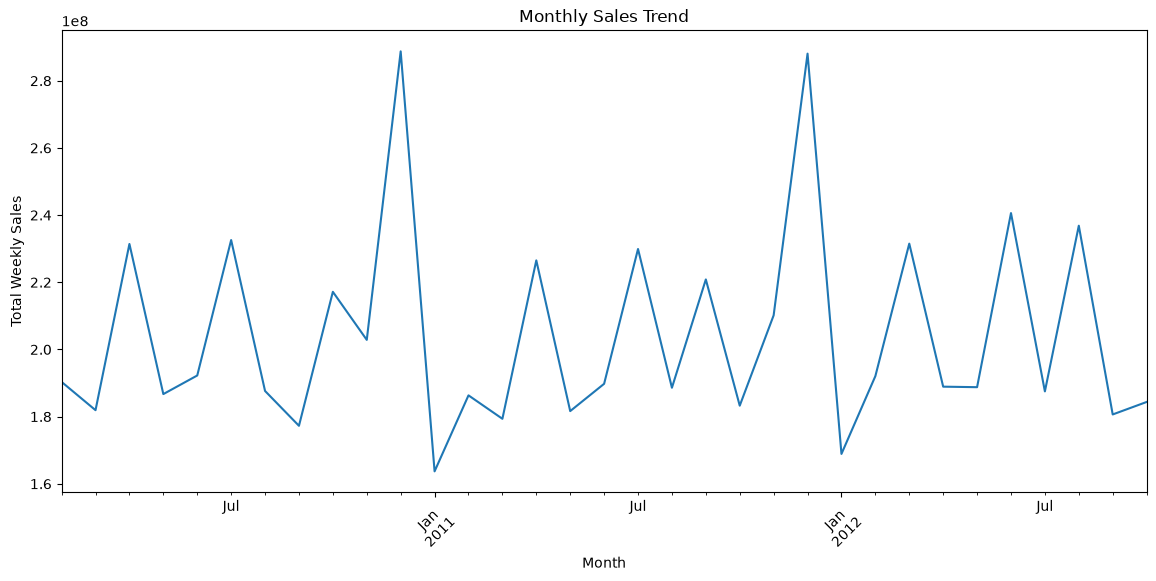

In [42]:
monthly_sales = final_data.groupby(
    final_data["Date"].dt.to_period("M")
)["Weekly_Sales"].sum()

plt.figure(figsize=(14, 6))

monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Weekly Sales")

plt.xticks(rotation=45)

plt.show()

Average Weekly Sales by Store Type:
Type
A    20099.568043
B    12237.075977
C     9519.532538
Name: Weekly_Sales, dtype: float64


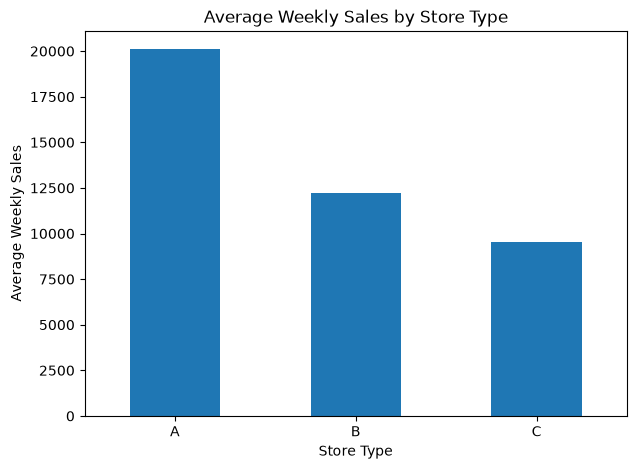

In [43]:
store_type_sales = final_data.groupby("Type")["Weekly_Sales"].mean().sort_values(ascending=False)

print("Average Weekly Sales by Store Type:")
print(store_type_sales)

plt.figure(figsize=(7, 5))

store_type_sales.plot(kind="bar")

plt.title("Average Weekly Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Weekly Sales")
plt.xticks(rotation=0)

plt.show()